# Setup

In [1]:
import math

import torch
import numpy as np
import scipy.stats as stats
import scipy.sparse as sprs
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  
import matplotlib.animation as pltanim
import umap
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

from data import MET_Data
import utils

/Users/ian.convy/miniconda3/envs/align/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
merge_map = utils.get_tree_merge_map("../data/meta/tree_Mouse_ALM-VISp_2018.csv", "n3")
def get_merge_func(index, merge_map = merge_map):
    merge_func = np.vectorize(lambda elem: merge_map[elem][index]) 
    return merge_func

def get_gaussian_data(num_clusters, num_samples, data_dim, mean_scale = 1.0, cluster_scale = 0.1, num_datasets = 2, rotate = False):
    ortho_gen = stats.ortho_group(data_dim)
    means = [np.random.normal(scale = mean_scale, size = [1, data_dim]) for _ in range(num_clusters)]
    variances = [np.random.normal(scale = cluster_scale, size = [num_samples, data_dim]) for _ in range(num_clusters)]
    transforms = [(ortho_gen.rvs() if rotate else np.eye(data_dim)) for _ in range(num_datasets)]
    clusters = [sum(vals) for vals in zip(means, variances)]
    raw_datasets = [np.concatenate(clusters, 0) @ transform for transform in transforms]
    datasets = [data - data.mean(0) for data in raw_datasets]
    labels = np.concatenate([np.full([num_samples], i) for i in range(num_clusters)])
    return (datasets, labels)

def get_L_data(num_samples, angle):
    angle = math.pi/15
    X = torch.zeros([num_samples, 2])
    num_vert = num_samples // 2
    X[:num_vert, 1] = torch.linspace(0, 2, num_vert)
    X[:num_vert, 0] = 0.1*torch.rand(size = [num_vert])
    X[num_vert:, 0] = torch.linspace(0, 2, num_samples - num_vert)
    X[num_vert:, 1] = 0.1*torch.rand(size = [num_samples - num_vert])
    Y = X @ torch.as_tensor([[math.cos(angle), -math.sin(angle)], [math.sin(angle), math.cos(angle)]])
    return ([X, Y], [torch.zeros([num_samples]), torch.zeros([num_samples])])

def get_arbor_data():
    data_keys = {"logcpm": "logcpm", "pca-ipfx": "pca-ipfx", "arbors": "arbors"}
    met_data = MET_Data("../data/neurons.hdf5", **data_keys)
    patch_data = met_data.query(formats = [("arbors",)], platforms = ["patchseq"], outputs = ["class", "arbors"])
    em_data = met_data.query(formats = [("arbors",)], platforms = ["EM"], outputs = ["class", "arbors"])
    (patch_samples, em_samples) = (patch_data["arbors"], em_data["arbors"])
    (patch_labels, em_labels) = (patch_data["class"], em_data["class"])
    return ([patch_samples, em_samples], [patch_labels, em_labels])

def get_morph_data(neuron_class = "exc"):
    met_data = MET_Data("../data/neurons.hdf5", **{"morphometric": "morphometric"})
    patch_data = met_data.query(formats = [("morphometric",)], platforms = ["patchseq"], classes = [neuron_class], outputs = ["class", "morphometric"])
    em_data = met_data.query(formats = [("morphometric",)], platforms = ["EM"], classes = [neuron_class], outputs = ["class", "morphometric"])
    valid_features = np.all(~np.isnan(em_data["morphometric"]), 0)
    (patch_samples, em_samples) = (patch_data["morphometric"], em_data["morphometric"])
    (patch_samples, em_samples) = (patch_samples[:, valid_features], em_samples[:, valid_features])
    (patch_labels, em_labels) = (patch_data["class"], em_data["class"])
    return ([em_samples, patch_samples], [em_labels, patch_labels])

def get_gene_data():
    data_keys = {"logcpm": "logcpm", "pca-ipfx": "pca-ipfx", "arbors": "arbors"}
    met_data = MET_Data("../data/neurons.hdf5", **data_keys)
    patch_data = met_data.query(formats = [("logcpm",)], platforms = ["patchseq"], outputs = ["cluster_label", "logcpm"])
    smart_data = met_data.query(formats = [("logcpm",)], platforms = ["smartseq"], outputs = ["cluster_label", "logcpm"])
    (patch_samples, smart_samples) = (patch_data["logcpm"], smart_data["logcpm"])
    (patch_labels, smart_labels) = (patch_data["cluster_label"], smart_data["cluster_label"])
    return ([patch_samples, smart_samples], [patch_labels, smart_labels])

def get_mutual_neighbors(reference, query, neighborhood_size, batch_size = 1000):
    (neighbors_ref, neighbors_query) = ([], [])
    for (data_1, data_2, results) in [(reference, query, neighbors_ref), (query, reference, neighbors_query)]:
        num_batches = math.ceil(len(data_1) / batch_size)
        for (start_i, end_i) in ((i*batch_size, (i+1)*batch_size) for i in range(num_batches)):
            print(f"Running {start_i+1}/{len(data_1)}            ", end = "\r")
            dist = torch.square(data_1[start_i:end_i, None] - data_2[None]).sum(-1)
            neighbors = torch.argsort(dist, -1)[:, :neighborhood_size]
            results.append(neighbors)
    (neighbors_ref, neighbors_query) = (torch.cat(neighbors_ref), torch.cat(neighbors_query))
    is_shared = (neighbors_query[neighbors_ref] == torch.arange(len(neighbors_ref))[:, None, None]).any(-1)
    ref_indices = torch.repeat_interleave(torch.arange(len(neighbors_ref)), neighborhood_size)
    paired = torch.stack([ref_indices, neighbors_ref.flatten()], -1)
    mutual_nn = paired[is_shared.flatten()]
    return mutual_nn

def get_correction(reference, query, mutual_neighbors, num_anchors, kernel_scale = 1.0, batch_size = 1000):
    (corrections, anchor_indices) = ([], [])
    for (start_i, end_i) in ((i*batch_size, (i+1)*batch_size) for i in range(math.ceil(len(query) / batch_size))):
        print(f"Running {start_i+1}/{len(query)}             ", end = "\r")
        ref_anchors = reference[mutual_neighbors[:, 0]]
        query_anchors = query[mutual_neighbors[:, 1]]
        query_dist = torch.square(query[start_i:end_i, None] - query_anchors[None]).sum(-1)**0.5
        nearest_anchors_index = torch.argsort(query_dist, -1)[:, :num_anchors]
        nearest_dists = query_dist[torch.arange(query_dist.shape[0])[:, None], nearest_anchors_index]
        #exp = torch.nan_to_num(nearest_dists/nearest_dists[:, -1:]) - 1
        kernel = torch.exp(-nearest_dists/kernel_scale)#1 + 0*(1 - torch.exp(0.25*exp))
        weights = kernel / kernel.sum(-1, keepdim = True)
        anchor_diff = ref_anchors[nearest_anchors_index] - query_anchors[nearest_anchors_index]
        correction = torch.einsum("nk,nkx->nx", weights, anchor_diff)
        corrections.append(correction)
        anchor_indices.append(nearest_anchors_index)
    (corrections, anchor_indices) = (torch.cat(corrections, 0), torch.cat(anchor_indices, 0))
    return (corrections, anchor_indices)

# Data

In [53]:
(datasets, labels) = get_gene_data() #get_L_data(patch_samples, math.pi/15)
datasets = [torch.as_tensor(arr).flatten(1) for arr in datasets]
normalize = False
batch_size = 128

In [54]:
(ref, query) = (ref_in, query_in) = datasets
if normalize:
    (ref_in, query_in) = (ref / torch.linalg.norm(ref, dim = 1, keepdim = True), query / torch.linalg.norm(query, dim = 1, keepdim = True))
print("Determining neighborhood...")
mutual_neighbors = get_mutual_neighbors(ref_in, query_in, 5, batch_size)
print("Completed.                           ")


Determining neighborhood...
Completed.                           


In [55]:
print("Computing correction...")
(correction, nearest_anchors) = get_correction(ref, query, mutual_neighbors, 100, 1.0, batch_size)
query_corr = query + correction
print("Completed.                           ")

Computing correction...
Completed.                           


## Data Plots

In [56]:
cell_pairs = mutual_neighbors
(ref_anchors, query_anchors, query_anchors_corr) = (ref[mutual_neighbors[:, 0]], query[mutual_neighbors[:, 1]], query_corr[mutual_neighbors[:, 1]])
ref_anchors_orig = ref_anchors_corr = ref_anchors
query_anchors_orig = query_anchors
(orig_comb, corr_comb) = (torch.cat([ref, query]), torch.cat([ref, query_corr]))
if ref_anchors.shape[-1] > 2:
    orig_map = umap.UMAP(min_dist = 0.55).fit(orig_comb)
    corr_map = umap.UMAP(min_dist = 0.55).fit(corr_comb)
    ref_anchors_orig = orig_map.transform(ref_anchors)
    ref_anchors_corr = corr_map.transform(ref_anchors)
    query_anchors_orig = orig_map.transform(query_anchors)
    query_anchors_corr = corr_map.transform(query_anchors_corr)
    orig_comb = orig_map.transform(orig_comb)
    corr_comb = corr_map.transform(corr_comb)

## L

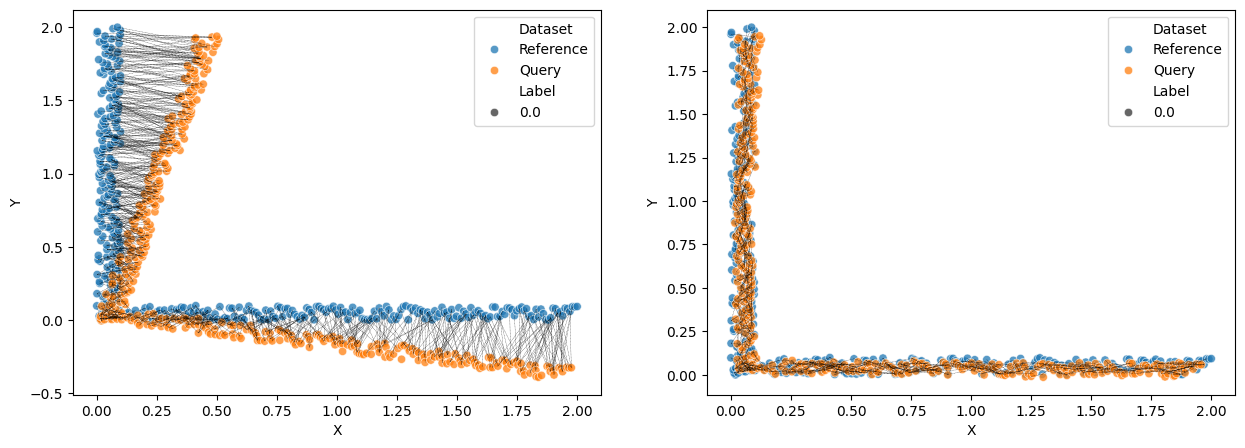

In [ ]:
pair_plot_frac = 0.1
orig_data = {
    "Dataset": len(ref)*["Reference"] + len(query)*["Query"],
    "Label": torch.cat(labels).tolist(),
    "X": orig_comb[:, 0].tolist(), "Y": orig_comb[:, 1].tolist()}
corr_data = {
    "Dataset": len(ref)*["Reference"] + len(query)*["Query"],
    "Label": torch.cat(labels).tolist(),
    "X": corr_comb[:, 0].tolist(), "Y": corr_comb[:, 1].tolist()}
(fig, (ax_orig, ax_corr)) = plt.subplots(1, 2, figsize = (15, 5))
sns.scatterplot(orig_data, ax = ax_orig, x = "X", y = "Y", hue = "Dataset", style = "Label", alpha = 0.75)
sns.scatterplot(corr_data, ax = ax_corr, x = "X", y = "Y", hue = "Dataset", style = "Label", alpha = 0.75)
if pair_plot_frac > 0:
    pair_i = torch.multinomial(torch.ones([len(mutual_neighbors)]), int(pair_plot_frac*len(mutual_neighbors)))
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_orig[pair_i], query_anchors_orig[pair_i]):
        ax_orig.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_corr[pair_i], query_anchors_corr[pair_i]):
        ax_corr.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
plt.show()

## Morphometric

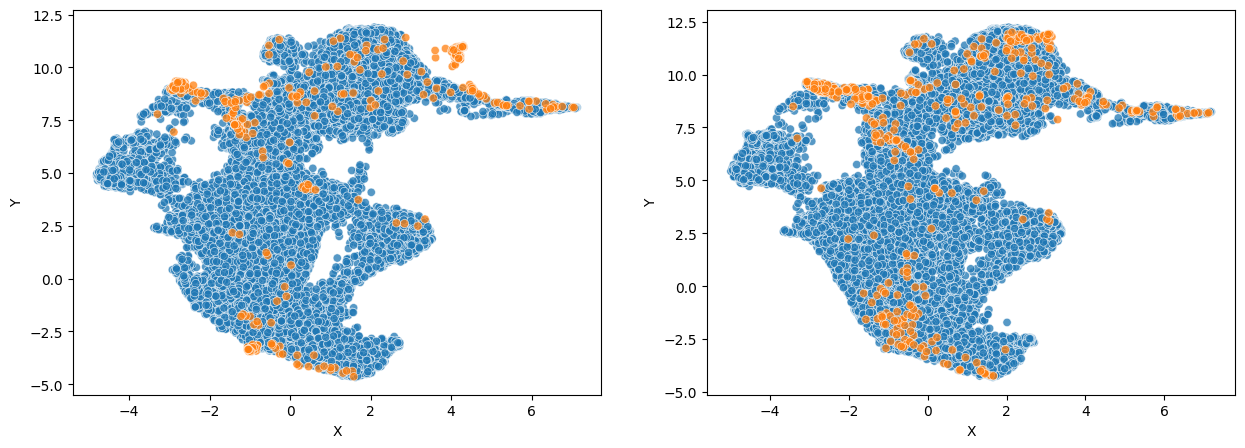

In [89]:
pair_plot_frac = 0.0
orig_data = {
    "Dataset": len(ref)*["Reference"] + len(query)*["Query"],
    "X": orig_comb[:, 0].tolist(), "Y": orig_comb[:, 1].tolist()}
corr_data = {
    "Dataset": len(ref)*["Reference"] + len(query)*["Query"],
    "X": corr_comb[:, 0].tolist(), "Y": corr_comb[:, 1].tolist()}
(fig, (ax_orig, ax_corr)) = plt.subplots(1, 2, figsize = (15, 5))
sns.scatterplot(orig_data, ax = ax_orig, x = "X", y = "Y", hue = "Dataset", alpha = 0.75)
sns.scatterplot(corr_data, ax = ax_corr, x = "X", y = "Y", hue = "Dataset", alpha = 0.75)
if pair_plot_frac > 0:
    pair_i = torch.multinomial(torch.ones([len(mutual_neighbors)]), int(pair_plot_frac*len(mutual_neighbors)))
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_orig[pair_i], query_anchors_orig[pair_i]):
        ax_orig.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_corr[pair_i], query_anchors_corr[pair_i]):
        ax_corr.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
ax_orig.legend([],[], frameon=False)
ax_corr.legend([],[], frameon=False)
plt.show()

## Transcriptomic

In [58]:
clusters = get_merge_func(-20)(np.char.strip(np.concatenate(labels, 0)))

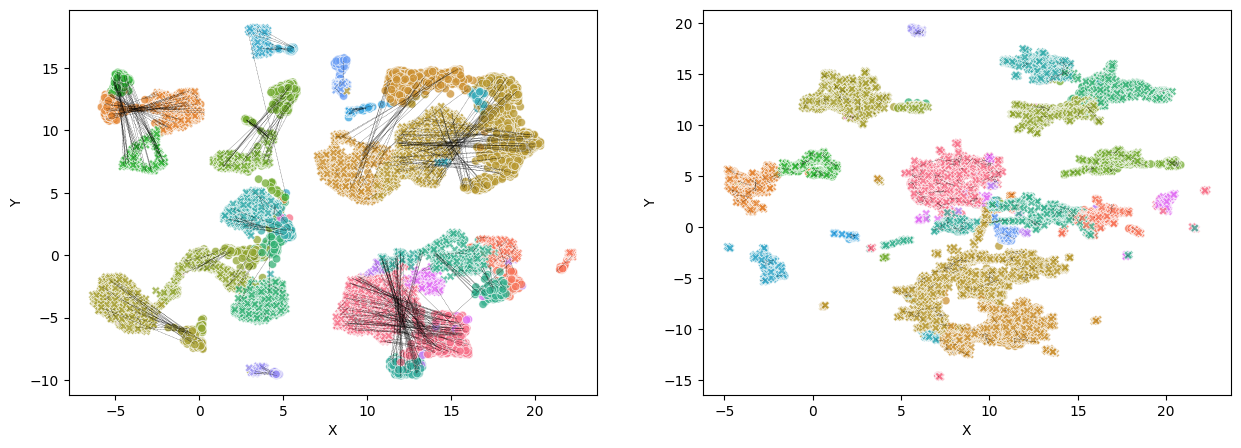

In [59]:
pair_plot_frac = 0.2
orig_data = {
    "Dataset": len(ref)*["Reference"] + len(query)*["Query"],
    "Label": clusters.tolist(),
    "X": orig_comb[:, 0].tolist(), "Y": orig_comb[:, 1].tolist()}
corr_data = {
    "Dataset": len(ref)*["Reference"] + len(query)*["Query"],
    "Label": clusters.tolist(),
    "X": corr_comb[:, 0].tolist(), "Y": corr_comb[:, 1].tolist()}
(fig, (ax_orig, ax_corr)) = plt.subplots(1, 2, figsize = (15, 5))
sns.scatterplot(orig_data, ax = ax_orig, x = "X", y = "Y", hue = "Label", style = "Dataset", alpha = 0.75)
sns.scatterplot(corr_data, ax = ax_corr, x = "X", y = "Y", hue = "Label", style = "Dataset", alpha = 0.75)
if pair_plot_frac > 0:
    pair_i = torch.multinomial(torch.ones([len(mutual_neighbors)]), int(pair_plot_frac*len(mutual_neighbors)))
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_orig[pair_i], query_anchors_orig[pair_i]):
        ax_orig.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_corr[pair_i], query_anchors_corr[pair_i]):
        ax_corr.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
ax_orig.legend([],[], frameon=False)
ax_corr.legend([],[], frameon=False)
plt.show()

# CCA

### Computation

In [249]:
feature_centered = [data - data.mean(1, keepdims = True) for data in datasets]
feature_normed = [data / data.std(1, keepdims = True) for data in datasets]

In [250]:
(x_vecs, sing_vals, y_vecs) = np.linalg.svd(feature_normed[0] @ feature_normed[1].T)

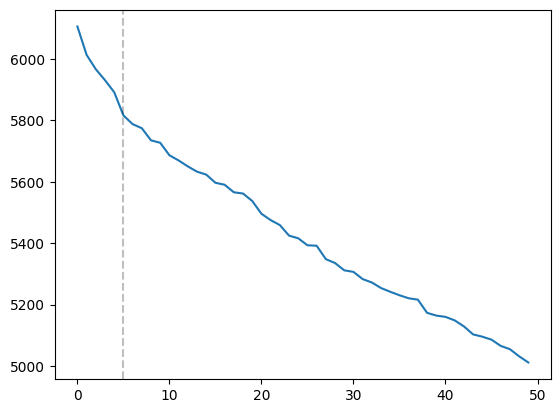

In [251]:
plt.plot(sing_vals[:50])
plt.axvline(x = num_clusters, color = "black", linestyle = "dashed", alpha = 0.25)
plt.show()

(array([  1.,   0.,   0.,   2.,   2.,   4.,   7.,  13.,  19.,  26.,  44.,
         45.,  69., 102., 102., 128., 154., 183., 239., 228., 259., 276.,
        270., 278., 294., 302., 273., 268., 239., 225., 183., 154., 147.,
        125., 100.,  67.,  53.,  40.,  24.,  19.,  10.,  11.,   5.,   5.,
          2.,   0.,   2.,   0.,   0.,   1.]),
 array([-0.05150191, -0.04936675, -0.04723158, -0.04509642, -0.04296126,
        -0.04082609, -0.03869093, -0.03655577, -0.0344206 , -0.03228544,
        -0.03015028, -0.02801511, -0.02587995, -0.02374479, -0.02160963,
        -0.01947446, -0.0173393 , -0.01520414, -0.01306897, -0.01093381,
        -0.00879865, -0.00666348, -0.00452832, -0.00239316, -0.00025799,
         0.00187717,  0.00401233,  0.00614749,  0.00828266,  0.01041782,
         0.01255298,  0.01468815,  0.01682331,  0.01895847,  0.02109364,
         0.0232288 ,  0.02536396,  0.02749912,  0.02963429,  0.03176945,
         0.03390461,  0.03603978,  0.03817494,  0.0403101 ,  0.04244527,
 

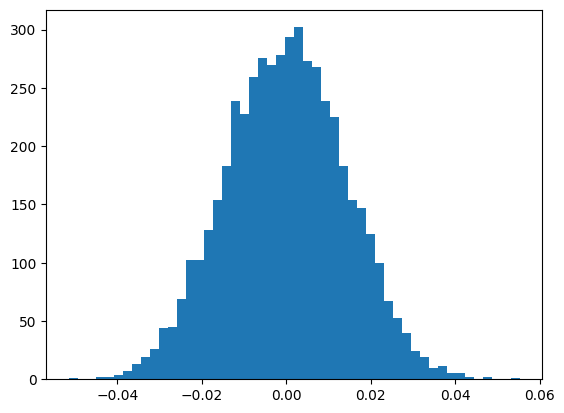

In [252]:
plt.hist(x_vecs[:, 3], 50)

### Plots

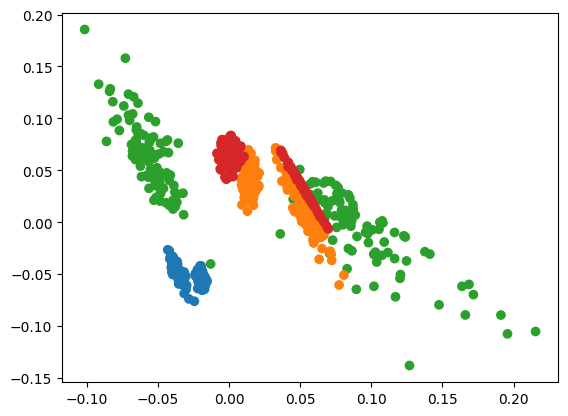

In [157]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(*np.concatenate([x_vecs, y_vecs.T], 0)[:, :2].T, c = 2*[f"C{i}" for i in labels])
plt.show()